# WEEK - 1

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use("seaborn-v0_8-talk")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.edgecolor"] = "0.3"
plt.rcParams["axes.linewidth"] = 0.8

In [2]:
tickers = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
start_long = "2015-01-01"
start_med = "2020-01-01"
end_date = "2024-01-01"

In [4]:

data = yf.download(tickers, start=start_long, end=end_date, auto_adjust=False)
adj_close = data['Adj Close']
full_range = pd.date_range(adj_close.index.min(), adj_close.index.max(), freq="B")
adj_close_full = adj_close.reindex(full_range).ffill().bfill()
adj_close = adj_close_full

[*********************100%***********************]  5 of 5 completed


In [5]:
print(adj_close.describe())

Ticker         AAPL         AMZN         GOOG         MSFT         TSLA
count   2346.000000  2346.000000  2346.000000  2346.000000  2346.000000
mean      81.399145    91.897109    73.044962   154.530904   102.871180
std       56.009808    48.624441    36.272358    99.667908   110.946343
min       20.604078    14.347500    24.377235    34.437160     9.578000
25%       32.795015    44.256876    41.486721    59.179596    16.668833
50%       51.187679    90.668247    59.376665   127.528820    23.160666
75%      138.766644   133.200001   104.143898   243.450859   214.390003
max      196.256546   186.570496   149.587067   377.077850   409.970001


In [6]:
df_long = adj_close
df_med = adj_close.loc[start_med:end_date]

In [8]:
# Asset under observation - AMZN
asset = 'AMZN'
price = df_med[asset]

In [9]:
ret_1d = price.pct_change().dropna()
ret_5d = price.pct_change(5).dropna()
ret_20d = price.pct_change(20).dropna()

log_ret_1d = np.log(price/price.shift(1)).dropna()
log_ret_5d = np.log(price/price.shift(5)).dropna()
log_ret_20d = np.log(price/price.shift(20)).dropna()

vol_5d = log_ret_1d.rolling(window=5).std().dropna()
vol_20d = log_ret_1d.rolling(window=20).std().dropna()
vol_60d = log_ret_1d.rolling(window=60).std().dropna()

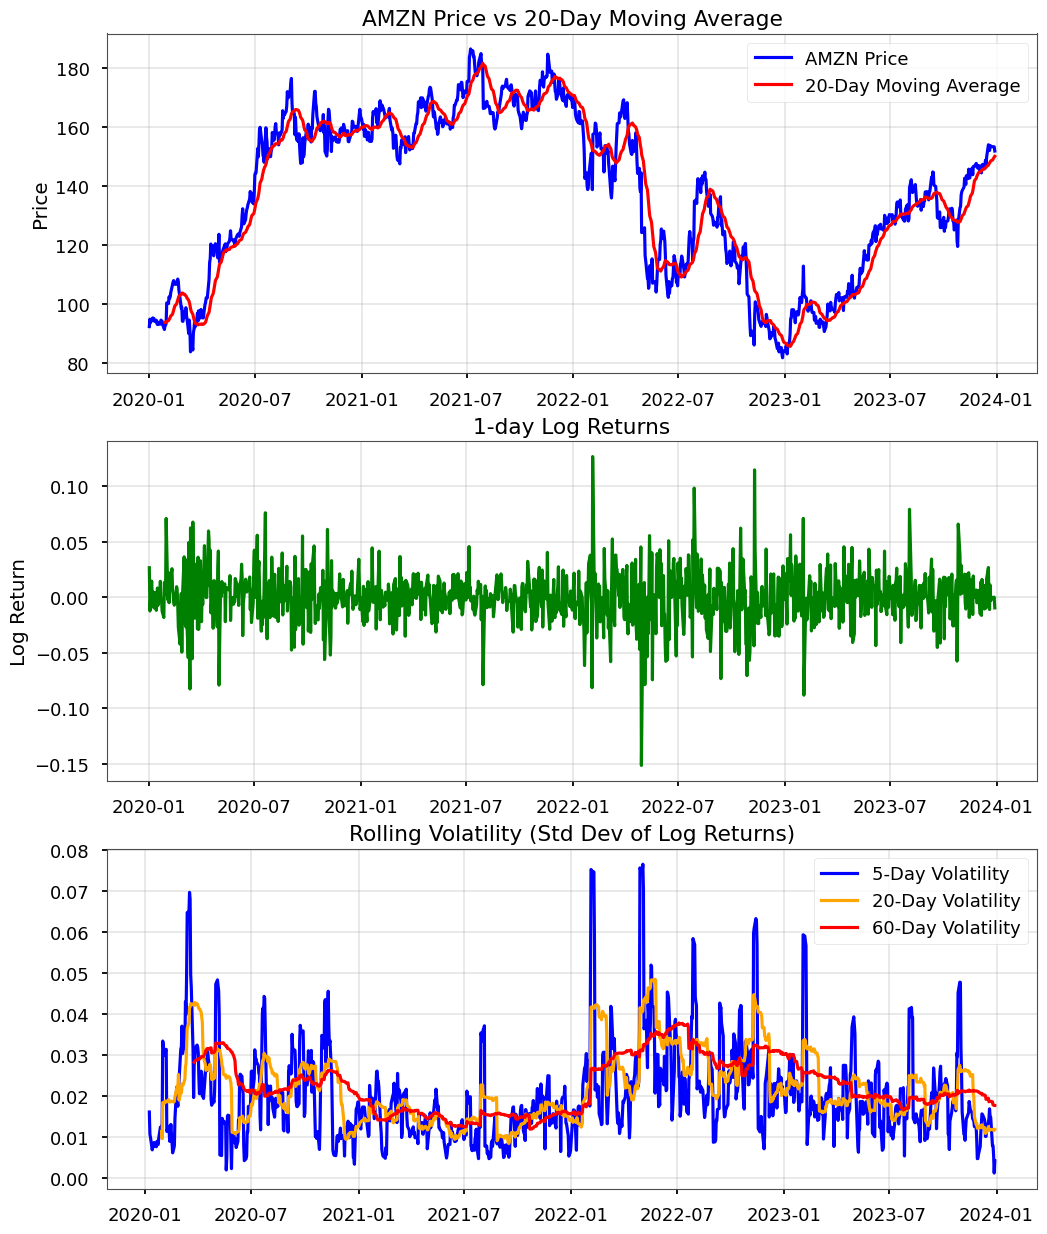

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

axes[0].plot(price, label=f'{asset} Price', color='blue')
axes[0].plot(price.rolling(20).mean(), label='20-Day Moving Average', color='red')
axes[0].set_title(f'{asset} Price vs 20-Day Moving Average')
axes[0].set_ylabel('Price')
axes[0].legend()

axes[1].plot(log_ret_1d, color='green')
axes[1].set_title('1-day Log Returns')
axes[1].set_ylabel('Log Return')

axes[2].plot(vol_5d, label='5-Day Volatility', color='blue')
axes[2].plot(vol_20d, label='20-Day Volatility', color='orange')
axes[2].plot(vol_60d, label='60-Day Volatility', color='red')
axes[2].set_title('Rolling Volatility (Std Dev of Log Returns)')
axes[2].legend()

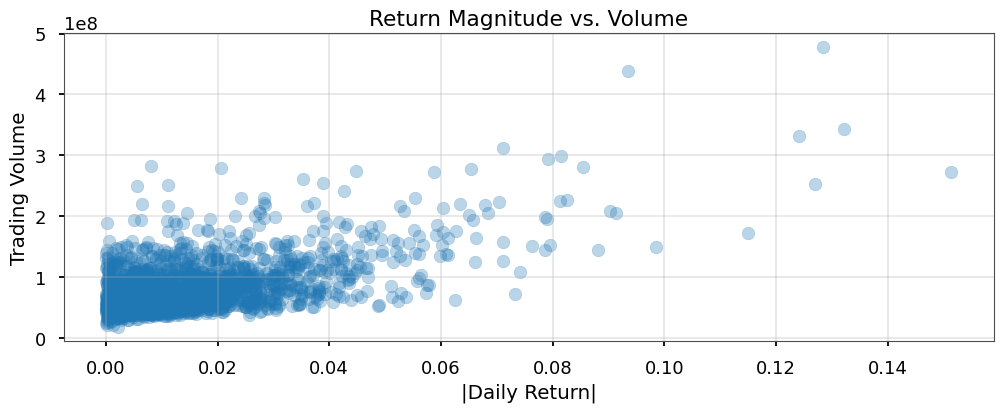

In [11]:
logret_long = np.log(data['Adj Close'][asset] / data['Adj Close'][asset].shift(1)).dropna()
volume = data['Volume'][asset].loc[logret_long.index]
plt.scatter(logret_long.abs(), volume, alpha=0.3)
plt.xlabel('|Daily Return|')
plt.ylabel('Trading Volume')
plt.title('Return Magnitude vs. Volume')
plt.show()

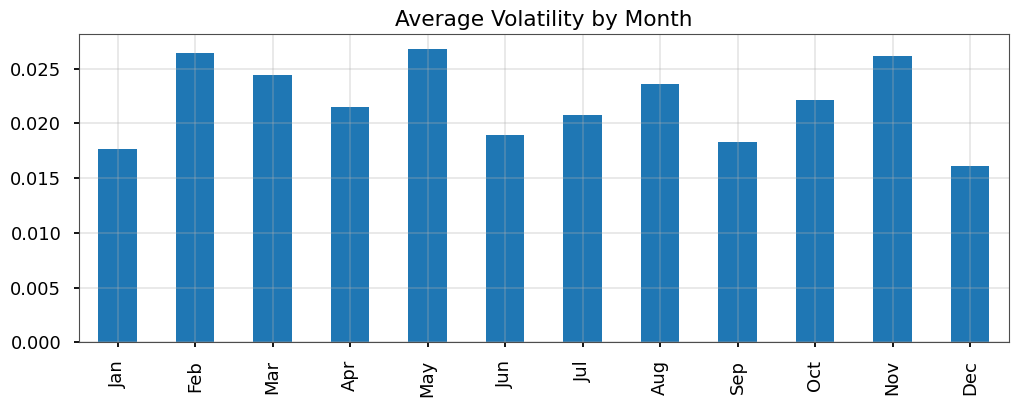

In [12]:
monthly_avg_vol = vol_20d.groupby(vol_20d.index.month).mean()
monthly_avg_vol.plot(kind='bar')
plt.title('Average Volatility by Month')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

In [14]:
returns = log_ret_1d

mean_20 = returns.rolling(window=20).mean()
mean_60 = returns.rolling(window=60).mean()
mean_120 = returns.rolling(window=120).mean()

std_20 = returns.rolling(window=20).std()
std_60 = returns.rolling(window=60).std()
std_120 = returns.rolling(window=120).std()

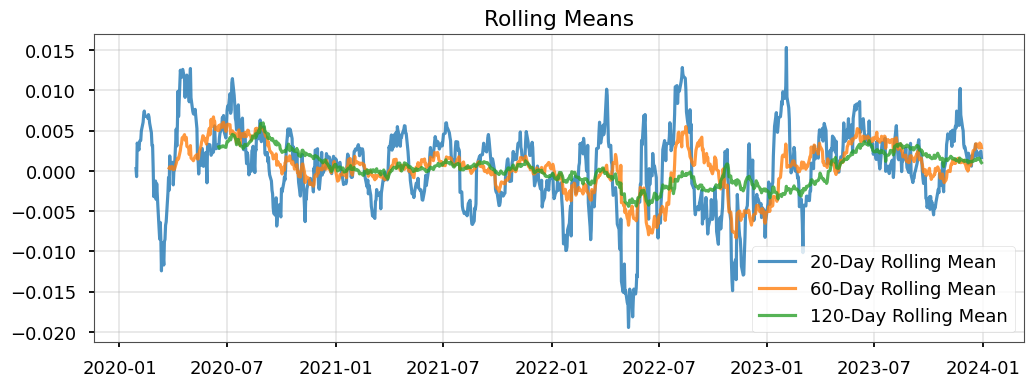

In [15]:
plt.plot(mean_20, label='20-Day Rolling Mean', alpha=0.8)
plt.plot(mean_60, label='60-Day Rolling Mean', alpha=0.8)
plt.plot(mean_120, label='120-Day Rolling Mean', alpha=0.8)
plt.title('Rolling Means')
plt.legend()
plt.show()

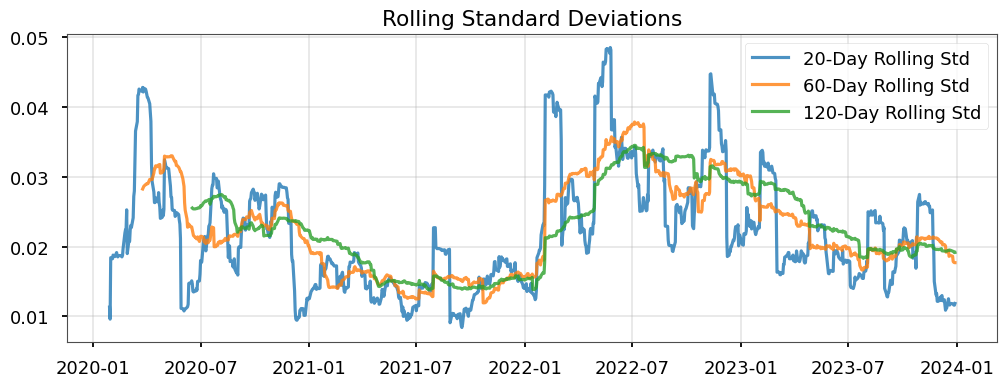

In [25]:
plt.plot(std_20, label='20-Day Rolling Std', alpha=0.8)
plt.plot(std_60, label='60-Day Rolling Std', alpha=0.8)
plt.plot(std_120, label='120-Day Rolling Std', alpha=0.8)
plt.title('Rolling Standard Deviations')
plt.legend()
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(returns)
print(f'p-value: {result[1]}')

if result[1] < 0.05:
    print("Reject H0: Stationary.")
else:
    print("Fail to reject H0: Non-stationary.")

p-value: 0.0
Reject H0: Stationary.


In [26]:
returns_t4 = returns.loc['2020-01-01':'2020-06-01']
vol_rolling = returns_t4.rolling(window=20).std()
vol_ewma = np.sqrt((returns_t4**2).ewm(alpha=0.06).mean())

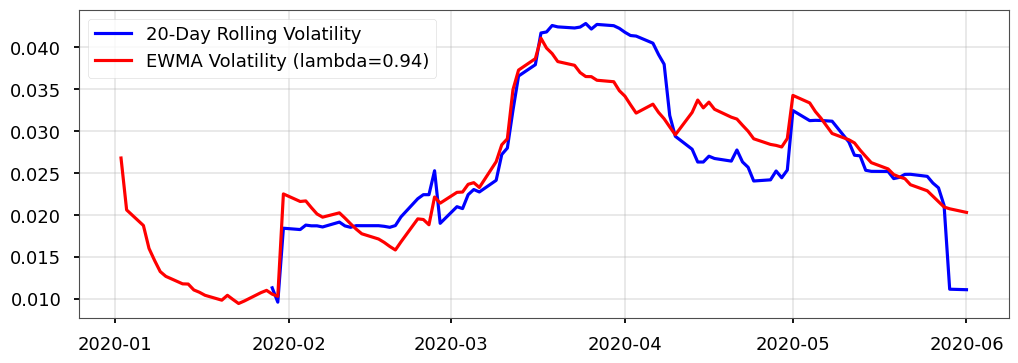

In [27]:
plt.plot(vol_rolling, label='20-Day Rolling Volatility', color='blue')
plt.plot(vol_ewma, label='EWMA Volatility (lambda=0.94)', color='red')
plt.legend()
plt.show()

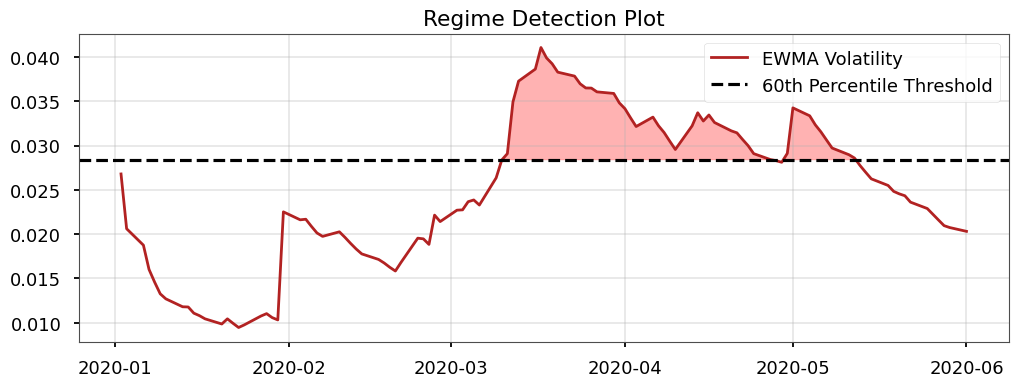

In [28]:
threshold = vol_ewma.quantile(0.60)
plt.plot(vol_ewma, label='EWMA Volatility', color='firebrick', lw=2)
plt.axhline(threshold, color='black', linestyle='--', label='60th Percentile Threshold')
plt.fill_between(vol_ewma.index, threshold, vol_ewma, where=(vol_ewma > threshold), color='red', alpha=0.3, interpolate=True)
plt.title('Regime Detection Plot')
plt.legend()
plt.show()

Variance of standardized returns: 0.9387


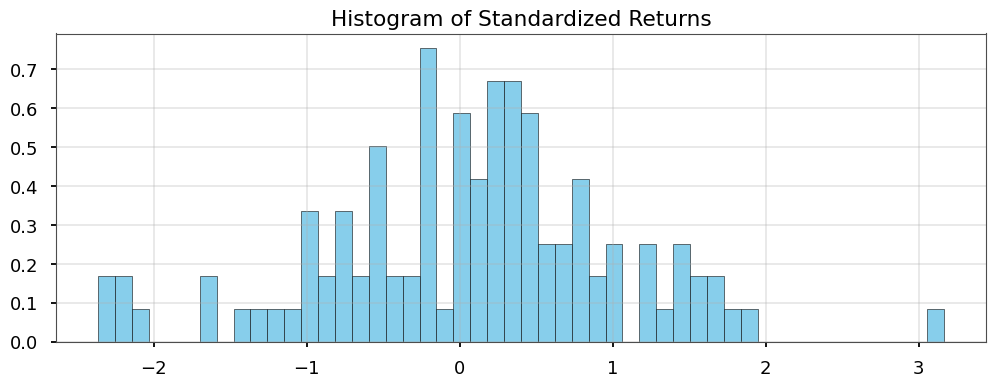

In [29]:
z_t = log_ret_1d / vol_ewma
variance_zt = z_t.var()
print(f"Variance of standardized returns: {variance_zt:.4f}")
plt.hist(z_t.dropna(), bins=50, density=True, color='skyblue', edgecolor='black')
plt.title('Histogram of Standardized Returns')
plt.show()

In [30]:
from scipy.stats import skew, kurtosis
# asset used here is TSLA
asset_price = df_long['TSLA']
price_weekly = asset_price.resample('W').last()
price_monthly = asset_price.resample('M').last()

log_ret_daily = np.log(asset_price / asset_price.shift(1)).dropna()
log_ret_weekly = np.log(price_weekly / price_weekly.shift(1)).dropna()
log_ret_monthly = np.log(price_monthly / price_monthly.shift(1)).dropna()

/tmp/ipython-input-2373399207.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  price_monthly = asset_price.resample('M').last()


In [31]:
for name, data in [("Daily", log_ret_daily), ("Weekly", log_ret_weekly), ("Monthly", log_ret_monthly)]:
    print(f"{name} : Skew = {skew(data)}, Kurtosis = {kurtosis(data, fisher=False)}")

Daily : Skew = -0.16239488590928736, Kurtosis = 7.775043953647091
Weekly : Skew = 0.07790521343973637, Kurtosis = 4.305134612123709
Monthly : Skew = 0.39411101875202253, Kurtosis = 3.603460974370445


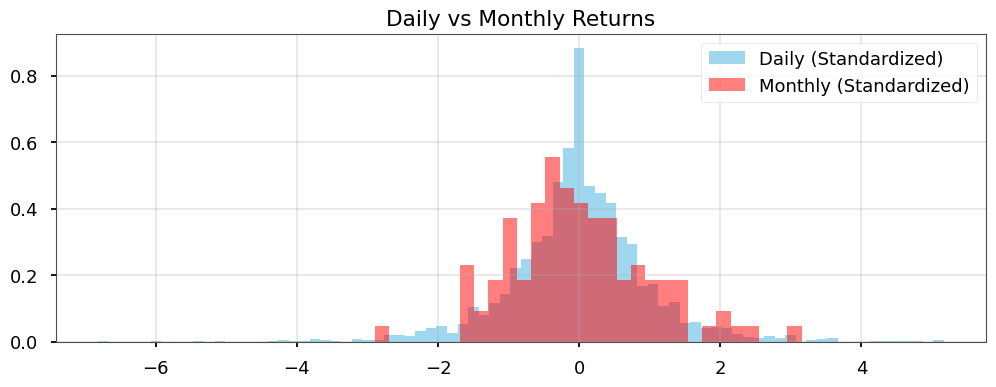

In [32]:
def standardize(s):
    return (s - s.mean()) / s.std()

plt.hist(standardize(log_ret_daily), bins=80, alpha=0.8, label='Daily (Standardized)', density=True, color='skyblue')
plt.hist(standardize(log_ret_monthly), bins=30, alpha=0.5, label='Monthly (Standardized)', density=True, color='red')
plt.title('Daily vs Monthly Returns')
plt.legend()
plt.show()

In [33]:
birth_date = "2006-05-29"
ticker = "NVDA"
data = yf.download(ticker, start=birth_date, auto_adjust=False)
adj_close = data['Adj Close']
p_birth = adj_close.iloc[0].item()
p_today = adj_close.iloc[-1].item()
investment = 1000
current_value = (p_today / p_birth) * investment
rtx_count = current_value / 1600
print(f"Price on birth date: ${p_birth:.2f}")
print(f"Price today: ${p_today:.2f}")
print(f"Value of $1,000 investment: ${current_value:,.2f}")
print(f"Number of RTX 4090s I can afford: {int(rtx_count)}")

[*********************100%***********************]  1 of 1 completed

Price on birth date: $0.35
Price today: $190.20
Value of $1,000 investment: $541,883.96
Number of RTX 4090s I can afford: 338


# WEEK - 2

In [34]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

plt.style.use("seaborn-v0_8")

In [35]:
asset = 'AMZN'
ticker = 'AMZN'
start_date = "2015-01-01"
end_date = "2024-01-01"

data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
prices = data['Adj Close']

full_range = pd.date_range(prices.index.min(), prices.index.max(), freq="B")
prices_full = prices.reindex(full_range).ffill().bfill()
prices = prices_full[asset]

[*********************100%***********************]  1 of 1 completed


In [37]:
logret = np.log(prices / prices.shift(1)).dropna()

features = pd.DataFrame(index=prices.index)
features['r_t'] = logret
features['r_t_-1'] = logret.shift(1)
features['rolling_mean_20'] = logret.rolling(window=20).mean()
features['rolling_vol_20'] = logret.rolling(window=20).std()
features['momentum_5'] = logret.rolling(window=5).sum()

In [38]:
target = logret.shift(-1)
df_model = pd.concat([features, target.rename('target')], axis=1).dropna()
X = df_model.drop(columns=['target'])
y = df_model['target']

In [39]:
y_pred_zero = np.zeros_like(y)

In [40]:
y_pred_rolling = X['rolling_mean_20']

In [41]:
from sklearn.linear_model import Ridge
lr_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)

In [42]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

In [43]:
tscv = TimeSeriesSplit(n_splits=5)
y_pred_lr = []
y_pred_rf = []
y_pred_ridge = []
true_y_list = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    lr_model.fit(X_train, y_train)
    lr_fold_preds = lr_model.predict(X_test)
    y_pred_lr.extend(lr_fold_preds)

    ridge_model.fit(X_train, y_train)
    ridge_fold_preds = ridge_model.predict(X_test)
    y_pred_ridge.extend(ridge_fold_preds)

    rf.fit(X_train, y_train)
    rf_fold_preds = rf.predict(X_test)
    y_pred_rf.extend(rf_fold_preds)

    true_y_list.extend(y_test)

In [44]:
test_index = pd.Series(y.index[-len(y_pred_lr):])
y_true = pd.Series(y.loc[test_index])
y_pred_zero = pd.Series(0, index=test_index)
y_pred_rolling = pd.Series(y_pred_rolling.loc[test_index])

rmse = {
    "Zero Predictor": np.sqrt(mean_squared_error(y_true, y_pred_zero)).item(),
    "Rolling Mean": np.sqrt(mean_squared_error(y_true, y_pred_rolling)).item(),
    "Linear Regression": np.sqrt(mean_squared_error(y_true, y_pred_lr)).item(),
    "Ridge Regression": np.sqrt(mean_squared_error(y_true, y_pred_ridge)).item(),
    "Random Forest": np.sqrt(mean_squared_error(y_true, y_pred_rf)).item()
}

print("Comparison of models (highest to lowest RMSE):")
for model, score in sorted(rmse.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: {score:.6f}")

Comparison of models (highest to lowest RMSE):
Rolling Mean: 0.020991
Random Forest: 0.020548
Linear Regression: 0.020519
Ridge Regression: 0.020478
Zero Predictor: 0.020469


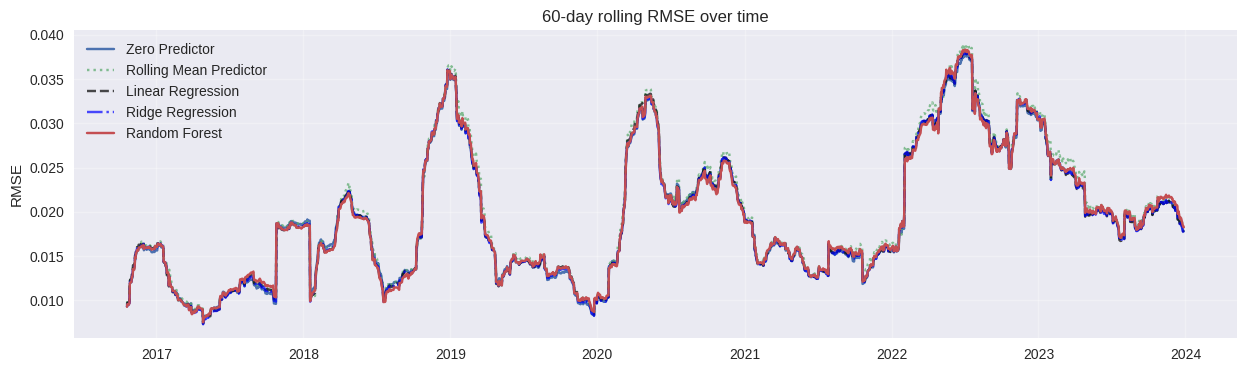

In [45]:
def get_rolling_rmse(actual, pred, win):
    squared_error = (actual - pred)**2
    return np.sqrt(squared_error.rolling(window=win).mean()).dropna()

window = 60
rmse_zero_roll = get_rolling_rmse(y_true, y_pred_zero, window)
rmse_roll_mean_roll = get_rolling_rmse(y_true, y_pred_rolling, window)
rmse_lr_roll = get_rolling_rmse(y_true, y_pred_lr, window)
rmse_ridge_roll = get_rolling_rmse(y_true, y_pred_ridge, window)
rmse_rf_roll = get_rolling_rmse(y_true, y_pred_rf, window)

plt.figure(figsize=(15, 4))
plt.plot(rmse_zero_roll, label='Zero Predictor')
plt.plot(rmse_roll_mean_roll, label='Rolling Mean Predictor', linestyle=':', alpha=0.7)
plt.plot(rmse_lr_roll, label='Linear Regression', color='black', linestyle='--', alpha=0.7)
plt.plot(rmse_ridge_roll, label='Ridge Regression', color='blue', linestyle='dashdot', alpha=0.7)
plt.plot(rmse_rf_roll, label='Random Forest')
plt.title(f'{window}-day rolling RMSE over time')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [46]:
vol_t = X['rolling_vol_20'].loc[test_index]

norm_err = {
    "Zero Predictor": (np.abs(y_true - y_pred_zero) / vol_t).mean(),
    "Rolling Mean": (np.abs(y_true - y_pred_rolling) / vol_t).mean(),
    "Linear Regression": (np.abs(y_true - y_pred_lr) / vol_t).mean(),
    "Ridge Regression": (np.abs(y_true - y_pred_ridge) / vol_t).mean(),
    "Random Forest": (np.abs(y_true - y_pred_rf) / vol_t).mean()
}

print("Comparison of models (highest to lowest normalized prediction error):")
for model, score in sorted(norm_err.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: {score:.6f}")

Comparison of models (highest to lowest normalized prediction error):
Rolling Mean: 0.836944
Random Forest: 0.823787
Linear Regression: 0.820215
Ridge Regression: 0.815997
Zero Predictor: 0.815781


In [47]:
strategy_df = pd.DataFrame(index=y_true.index)
strategy_df['Actual Return'] = y_true

predictions = {
    "Zero Predictor": y_pred_zero,
    "Rolling Mean": y_pred_rolling,
    "Linear Regression": pd.Series(y_pred_lr, index=y_true.index),
    "Ridge Regression": pd.Series(y_pred_ridge, index=y_true.index),
    "Random Forest": pd.Series(y_pred_rf, index=y_true.index),
}

for name, preds in predictions.items():
    pos_col = f'{name} Position'
    ret_col = f'{name} Return'
    strategy_df[pos_col] = np.sign(preds)
    strategy_df[ret_col] = strategy_df[pos_col] * strategy_df['Actual Return']
    strategy_df[f'{name} Cumulative Growth'] = np.exp(strategy_df[ret_col].cumsum())

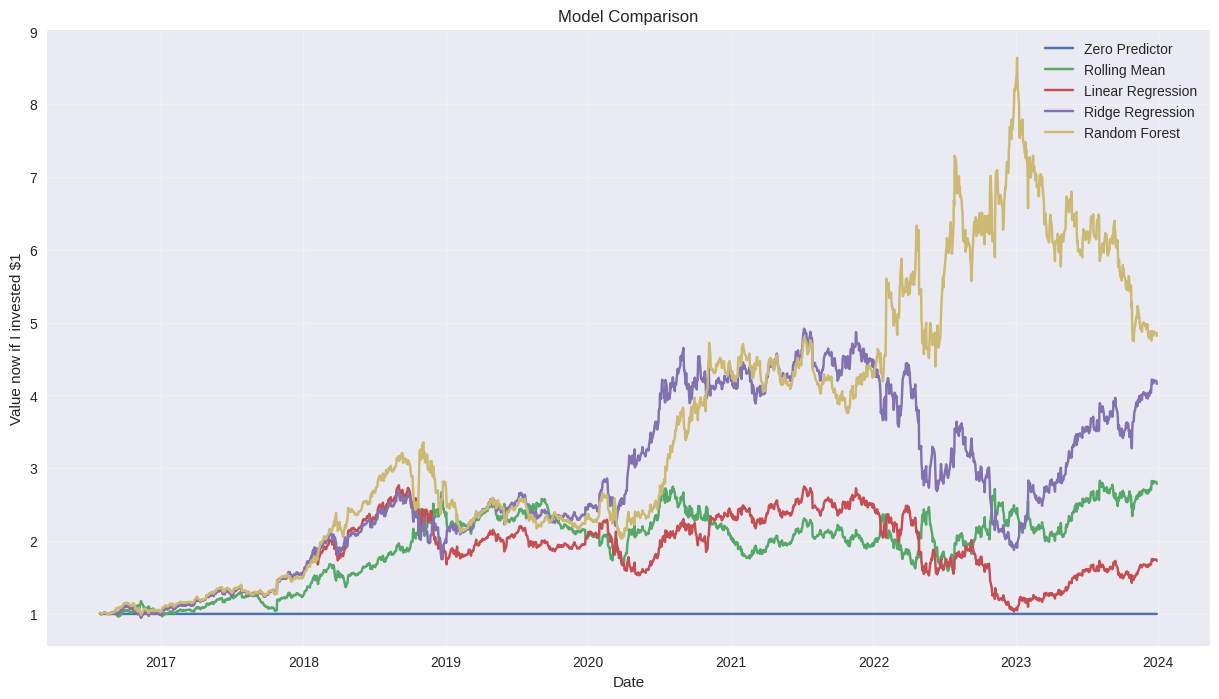

In [48]:
plt.figure(figsize=(15, 8))
for i, name in enumerate(predictions.keys()):
    plt.plot(strategy_df[f'{name} Cumulative Growth'], label=name)

plt.title('Model Comparison')
plt.ylabel('Value now if I invested $1')
plt.xlabel('Date')
plt.legend()
plt.show()

# Discussion:
Naïve baselines are essential to establish a minimum performance benchmark. In time-series forecasting, strong temporal dependencies often allow simple persistence-based models to perform reasonably well. Any advanced model must outperform these baselines to justify its complexity.

The evaluation strategy used is walk-forward validation, where the model is trained on historical data and tested on future observations. This differs from conventional random train–test splits, which shuffle data and violate temporal ordering. Random splitting fails in this context due to data leakage, leading to unrealistically optimistic performance estimates.

RMSE values quantify the average prediction error, while rolling RMSE highlights how model performance evolves over time. Periodic spikes in rolling RMSE indicate reduced accuracy during high-volatility or regime-change periods, suggesting sensitivity to non-stationary market behavior.

Random Forest models may overfit due to deep trees capturing noise, high feature dimensionality, and strong autocorrelation in time-series data, resulting in degraded forward performance.

Although two models may show similar RMSE, a model whose larger errors occur primarily during high-volatility periods may be less risky in a portfolio context, as exposure is typically reduced during such periods, limiting real financial impact.